<a href="https://colab.research.google.com/github/Delean-Mafra/faculdade/blob/main/Arquitetura_de_BI_e_Big_Data_com_Ciencia_de_Dados_Aplicada/Pratica_do_SCM_Anal%C3%ADtico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SISTEMA] Carregando DataFrames para a memória...
--- RESUMO DA QUALIDADE DOS DADOS ---
PRODUTOS        | Linhas: 5     | Nulos: 0   | Duplicatas: 0  
FORNECEDORES    | Linhas: 3     | Nulos: 0   | Duplicatas: 0  
DEMANDA         | Linhas: 3650  | Nulos: 0   | Duplicatas: 0  
PEDIDOS         | Linhas: 500   | Nulos: 0   | Duplicatas: 0  
ROTAS           | Linhas: 10    | Nulos: 0   | Duplicatas: 0  
ESTOQUE         | Linhas: 3650  | Nulos: 0   | Duplicatas: 0  
-------------------------------------

[SISTEMA] Gerando visualizações de dados...


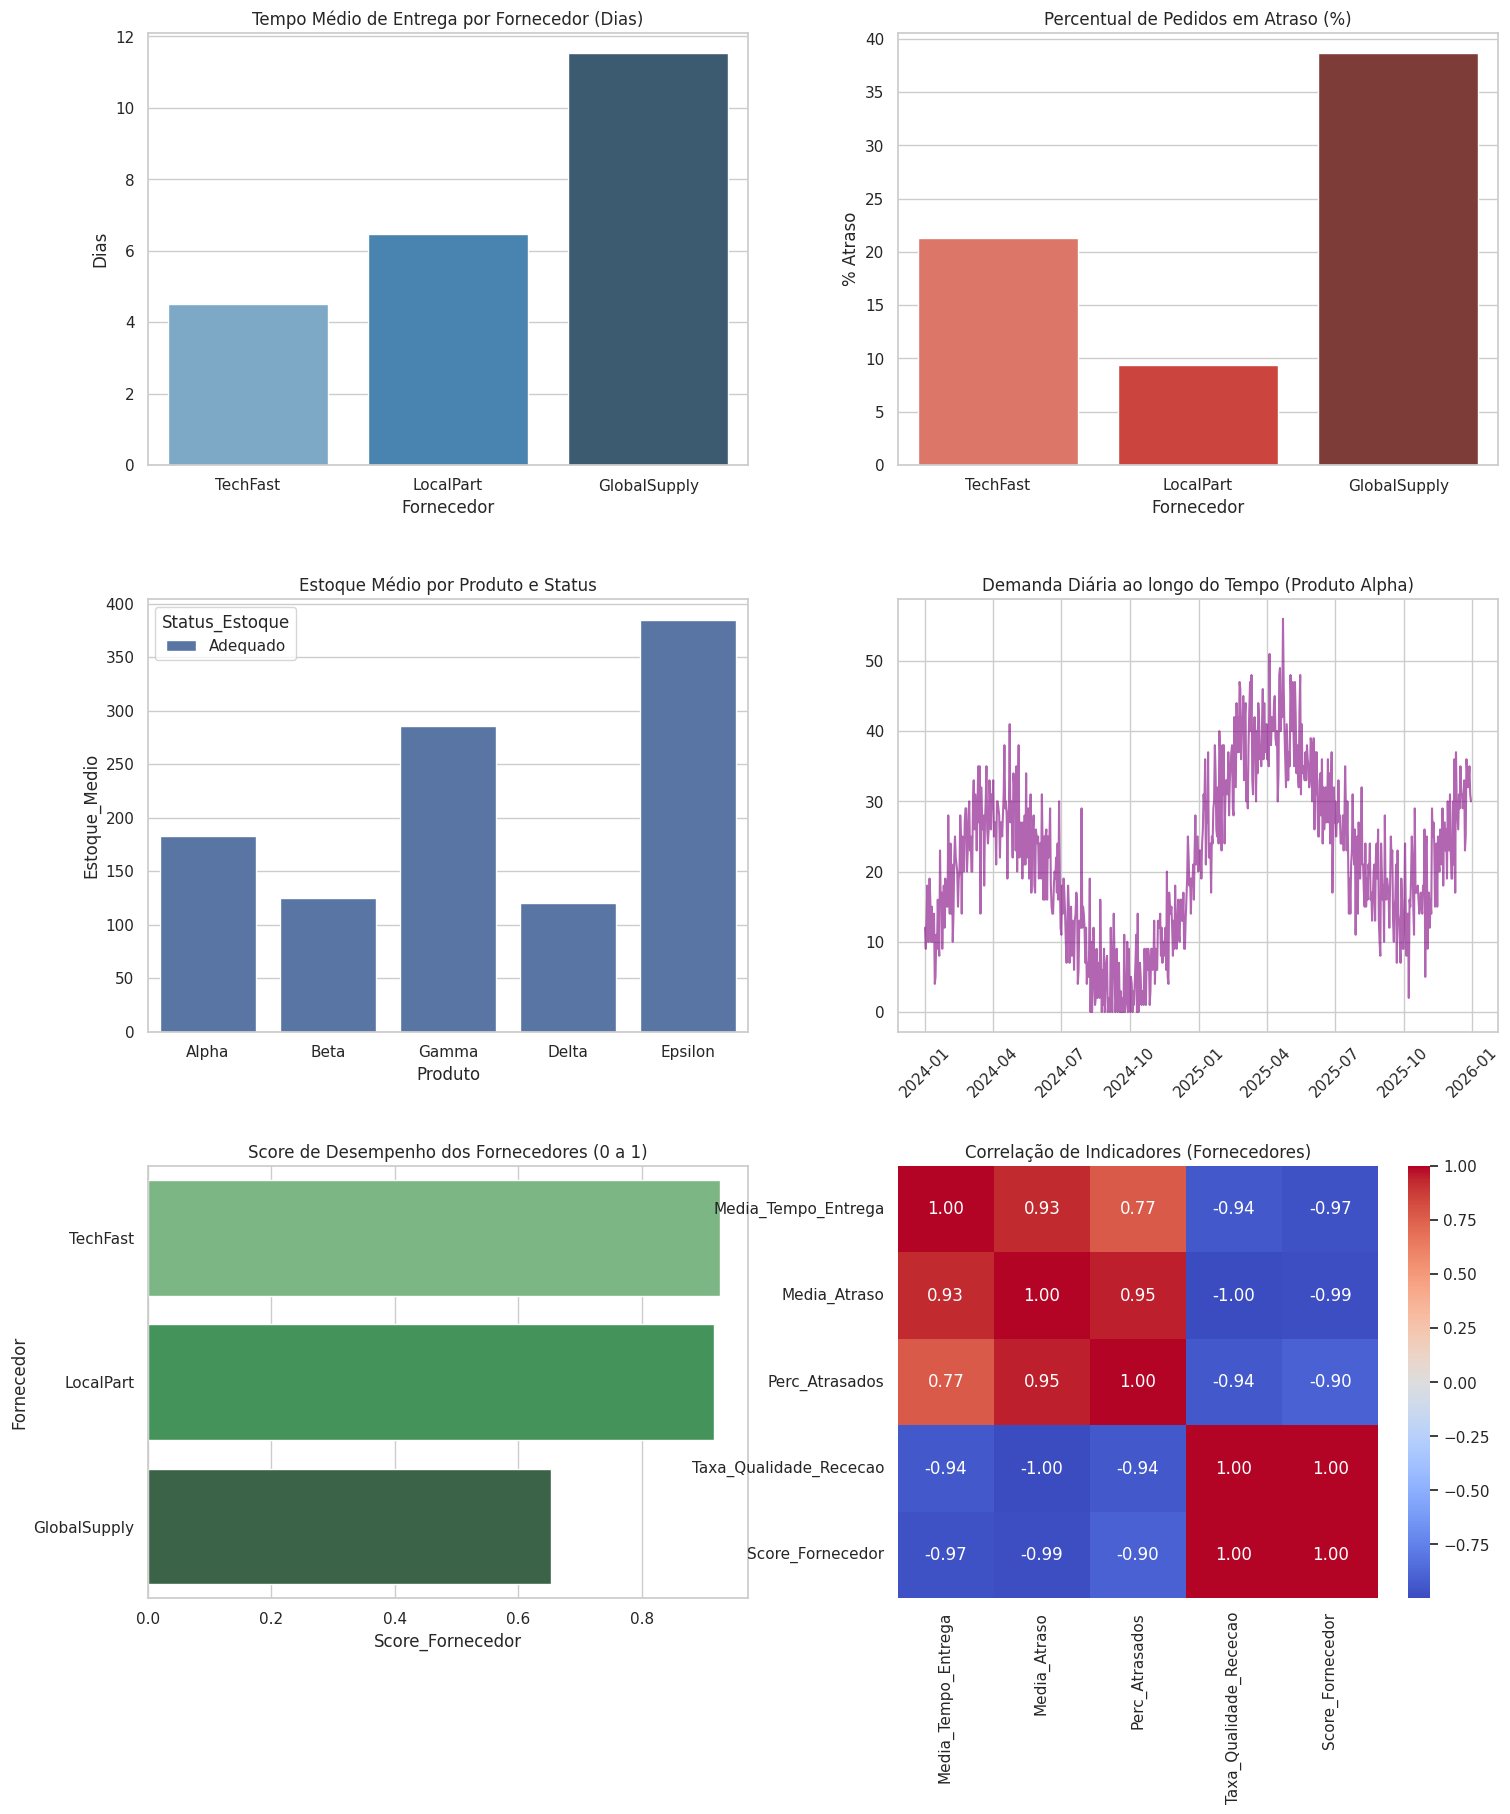

[SISTEMA] Gráficos exibidos com sucesso.

--- [ETAPA MACHINE LEARNING] PREVISÃO DE DEMANDA (XGBOOST) ---

--- PERFORMANCE DO MODELO E PREVISÃO PARA OS PRÓXIMOS 30 DIAS ---
 Produto_ID  Demanda Prevista 30d  Média Diária Prevista MAPE (Teste)  RMSE (Teste)
          1                1037.0              34.580002       32.74%          5.63
          2                1150.0              38.340000       16.63%          4.68
          3                1294.0              43.119999       13.97%          4.96
          4                1423.0              47.430000       17.15%          6.06
          5                1524.0              50.810001       13.52%          5.75

--- [ETAPA PO] OTIMIZAÇÃO DE COMPRAS ---
Produto   Fornecedor  Quantidade Recomendada  Custo Unitário  Custo Transporte  Custo Total
  Alpha GlobalSupply                     500          135.00               8.0     67508.00
  Alpha    LocalPart                     405          150.00              12.0     60739.93
   Bet

In [20]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import timedelta
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

try:
    import pulp
    PULP_AVAILABLE = True
except ImportError:
    PULP_AVAILABLE = False

# ==============================================================================
# 1 E 2: GERAÇÃO E IMPORTAÇÃO DOS DADOS SINTÉTICOS (BASE SCM)
# ==============================================================================
def gerar_dados_scm():
    print("[SISTEMA] Gerando base de dados sintética de SCM...")
    np.random.seed(42)

    produtos = pd.DataFrame({
        'Produto_ID': range(1, 6),
        'Produto': ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon'],
        'Categoria': ['Eletrônicos', 'Eletrônicos', 'Mecânica', 'Mecânica', 'Insumos'],
        'Estoque_Inicial': [500, 300, 800, 150, 1000],
        'Estoque_Minimo': [100, 50, 200, 50, 300],
        'Estoque_Maximo': [1000, 800, 1500, 400, 2500],
        'Custo_Unitario': [150.0, 350.0, 45.0, 85.0, 15.0]
    })

    fornecedores = pd.DataFrame({
        'ID_Fornecedor': ['F1', 'F2', 'F3'],
        'Fornecedor': ['TechFast', 'GlobalSupply', 'LocalPart'],
        'Lead_Time_Medio_Dias': [5.0, 12.0, 7.0],
        'Desvio_Padrao_LT': [1.2, 4.5, 0.8],
        'Taxa_Qualidade_Rececao': [0.98, 0.85, 0.99],
        'Taxa_Pontualidade': [0.95, 0.70, 0.92],
        'Custo_Unitario_Mult': [1.05, 0.90, 1.00],
        'Custo_Transporte': [15.0, 8.0, 12.0]
    })

    dias = pd.date_range(start='2024-01-01', periods=730, freq='D')
    dados_demanda = []
    for p_id in produtos['Produto_ID']:
        tendencia = np.linspace(10, 30 + (p_id*5), 730)
        sazonalidade = (15 + p_id) * np.sin(np.arange(730) * (2 * np.pi / 365))
        ruido = np.random.normal(0, 5, 730)
        demanda_arr = np.maximum(0, tendencia + sazonalidade + ruido).astype(int)

        df_d = pd.DataFrame({
            'Data': dias,
            'Produto_ID': p_id,
            'Demanda_Diaria': demanda_arr,
            'Dia_Semana': dias.dayofweek,
            'Mes': dias.month,
            'Sazonalidade': sazonalidade
        })
        dados_demanda.append(df_d)
    df_demanda = pd.concat(dados_demanda, ignore_index=True)

    pedidos = []
    for _ in range(500):
        data_ped = np.random.choice(dias[:-30])
        f_id = np.random.choice(['F1', 'F2', 'F3'], p=[0.4, 0.4, 0.2])
        p_id = np.random.randint(1, 6)
        qtd = np.random.randint(50, 300)

        f_info = fornecedores[fornecedores['ID_Fornecedor'] == f_id].iloc[0]
        lt_previsto = f_info['Lead_Time_Medio_Dias']
        lt_real = max(1, int(np.random.normal(lt_previsto, f_info['Desvio_Padrao_LT'])))

        data_prev = pd.to_datetime(data_ped) + timedelta(days=int(lt_previsto))
        data_real = pd.to_datetime(data_ped) + timedelta(days=lt_real)

        pedidos.append({
            'ID_Pedido': f"PED-{np.random.randint(10000, 99999)}",
            'Produto_ID': p_id,
            'Fornecedor_ID': f_id,
            'Data_Pedido': data_ped,
            'Data_Entrega_Prevista': data_prev,
            'Data_Entrega_Real': data_real,
            'Quantidade': qtd,
            'Custo_Transporte': f_info['Custo_Transporte'],
            'Status': 'Entregue'
        })
    df_pedidos = pd.DataFrame(pedidos)

    df_rotas = pd.DataFrame({
        'Cliente_ID': range(10),
        'Latitude': [50, 10, 40, 90, 80, 20, 60, 30, 70, 15],
        'Longitude': [50, 20, 80, 30, 90, 40, 10, 70, 60, 85],
        'Demanda': [0, 15, 20, 10, 25, 12, 18, 8, 22, 14],
        'Prioridade': [0, 1, 2, 1, 3, 2, 1, 3, 1, 2]
    })

    estoque = []
    for p_id in produtos['Produto_ID']:
        estq_atual = produtos.loc[produtos['Produto_ID']==p_id, 'Estoque_Inicial'].values[0]
        demanda_prod = df_demanda[df_demanda['Produto_ID']==p_id].sort_values('Data')

        for _, row in demanda_prod.iterrows():
            d = row['Demanda_Diaria']
            entrada = 200 if estq_atual < produtos.loc[produtos['Produto_ID']==p_id, 'Estoque_Minimo'].values[0] else 0
            estoque.append({
                'Data': row['Data'],
                'Produto_ID': p_id,
                'Estoque_Inicial': estq_atual,
                'Entradas': entrada,
                'Saidas': d,
                'Estoque_Final': estq_atual + entrada - d,
                'Demanda': d
            })
            estq_atual = max(0, estq_atual + entrada - d)
    df_estoque = pd.DataFrame(estoque)

    produtos.to_csv('produtos.csv', index=False)
    fornecedores.to_csv('fornecedores.csv', index=False)
    df_demanda.to_csv('demanda.csv', index=False)
    df_pedidos.to_csv('pedidos.csv', index=False)
    df_rotas.to_csv('rotas.csv', index=False)
    df_estoque.to_csv('estoque.csv', index=False)
    print("[SISTEMA] Arquivos CSV gerados com sucesso localmente.\n")

def carregar_dados_scm(url_google_drive=""):
    if url_google_drive:
        try:
            import gdown
            print(f"[SISTEMA] Tentando baixar dados via gdown da URL: {url_google_drive}")
            output = 'dados_scm.zip'
            gdown.download(url_google_drive, output, quiet=False)
            import zipfile
            with zipfile.ZipFile(output, 'r') as zip_ref:
                zip_ref.extractall('.')
            print("[SISTEMA] Dados baixados e extraídos.")
        except Exception as e:
            print(f"[AVISO] Falha no gdown ({e}). Utilizando geração local.")
            gerar_dados_scm()
    else:
        arquivos = ['produtos.csv', 'fornecedores.csv', 'demanda.csv', 'pedidos.csv', 'rotas.csv', 'estoque.csv']
        if not all(os.path.exists(f) for f in arquivos):
            gerar_dados_scm()

    print("[SISTEMA] Carregando DataFrames para a memória...")
    dfs = {
        'produtos': pd.read_csv('produtos.csv'),
        'fornecedores': pd.read_csv('fornecedores.csv'),
        'demanda': pd.read_csv('demanda.csv', parse_dates=['Data']),
        'pedidos': pd.read_csv('pedidos.csv', parse_dates=['Data_Pedido', 'Data_Entrega_Prevista', 'Data_Entrega_Real']),
        'rotas': pd.read_csv('rotas.csv'),
        'estoque': pd.read_csv('estoque.csv', parse_dates=['Data'])
    }

    print("--- RESUMO DA QUALIDADE DOS DADOS ---")
    for nome, df in dfs.items():
        nulos = df.isnull().sum().sum()
        duplicatas = df.duplicated().sum()
        print(f"{nome.upper():<15} | Linhas: {len(df):<5} | Nulos: {nulos:<3} | Duplicatas: {duplicatas:<3}")
    print("-" * 37 + "\n")
    return dfs

# ==============================================================================
# ETAPA 1 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# ==============================================================================
def analise_entregas(df_pedidos, df_fornecedores):
    df_pedidos['Tempo_Entrega'] = (df_pedidos['Data_Entrega_Real'] - df_pedidos['Data_Pedido']).dt.days
    df_pedidos['Atraso'] = (df_pedidos['Data_Entrega_Real'] - df_pedidos['Data_Entrega_Prevista']).dt.days
    df_pedidos['Atraso'] = df_pedidos['Atraso'].apply(lambda x: max(0, x))
    df_pedidos['Em_Atraso'] = df_pedidos['Atraso'] > 0

    piores_pedidos = df_pedidos.sort_values('Atraso', ascending=False).head(5)

    kpis_fornecedor = df_pedidos.groupby('Fornecedor_ID').agg(
        Media_Tempo_Entrega=('Tempo_Entrega', 'mean'),
        Mediana_Tempo_Entrega=('Tempo_Entrega', 'median'),
        Media_Atraso=('Atraso', 'mean'),
        Perc_Atrasados=('Em_Atraso', lambda x: x.mean() * 100)
    ).reset_index()

    kpis_fornecedor = kpis_fornecedor.merge(df_fornecedores, left_on='Fornecedor_ID', right_on='ID_Fornecedor')
    pior_fornecedor = kpis_fornecedor.loc[kpis_fornecedor['Perc_Atrasados'].idxmax()]

    return df_pedidos, kpis_fornecedor, piores_pedidos, pior_fornecedor

def analise_estoque(df_estoque, df_produtos):
    resumo_estoque = df_estoque.groupby('Produto_ID').agg(
        Estoque_Medio=('Estoque_Final', 'mean'),
        Demanda_Media=('Demanda', 'mean'),
        Desvio_Demanda=('Demanda', 'std'),
        Dias_Ruptura=('Estoque_Final', lambda x: (x <= 0).sum())
    ).reset_index()

    resumo_estoque = resumo_estoque.merge(
        df_produtos[['Produto_ID', 'Produto', 'Estoque_Minimo', 'Estoque_Maximo']],
        on='Produto_ID'
    )

    resumo_estoque['Cobertura_Dias'] = resumo_estoque['Estoque_Medio'] / (resumo_estoque['Demanda_Media'] + 0.001)

    df_temp = df_estoque[['Produto_ID', 'Estoque_Final']].merge(
        df_produtos[['Produto_ID', 'Estoque_Maximo']], on='Produto_ID'
    )
    excesso = df_temp[df_temp['Estoque_Final'] > df_temp['Estoque_Maximo']]
    dias_excesso = excesso.groupby('Produto_ID').size().reset_index(name='Dias_Excesso')

    resumo_estoque = resumo_estoque.merge(dias_excesso, on='Produto_ID', how='left')
    resumo_estoque['Dias_Excesso'] = resumo_estoque['Dias_Excesso'].fillna(0)

    def classificar_estoque(row):
        if row['Dias_Ruptura'] > 30: return "Insuficiente"
        elif row['Dias_Excesso'] > 30: return "Excessivo"
        else: return "Adequado"

    resumo_estoque['Status_Estoque'] = resumo_estoque.apply(classificar_estoque, axis=1)
    return resumo_estoque

def analise_fornecedores(kpis_fornecedor):
    # Pesos claramente documentados conforme exigência
    PESO_PONTUALIDADE = 0.25
    PESO_QUALIDADE = 0.25
    PESO_LEAD_TIME = 0.20
    PESO_VARIABILIDADE = 0.15
    PESO_CUSTO = 0.15

    kf = kpis_fornecedor.copy()

    # Normalização garantindo que maior pontuação = melhor desempenho
    norm_pontualidade = kf['Taxa_Pontualidade'] / kf['Taxa_Pontualidade'].max()
    norm_qualidade = kf['Taxa_Qualidade_Rececao'] / kf['Taxa_Qualidade_Rececao'].max()

    # Variáveis onde o menor valor é o melhor
    norm_lt = kf['Media_Tempo_Entrega'].min() / kf['Media_Tempo_Entrega']
    norm_var = kf['Desvio_Padrao_LT'].min() / kf['Desvio_Padrao_LT']
    norm_custo = kf['Custo_Unitario_Mult'].min() / kf['Custo_Unitario_Mult']

    kf['Score_Fornecedor'] = (
        (norm_pontualidade * PESO_PONTUALIDADE) +
        (norm_qualidade * PESO_QUALIDADE) +
        (norm_lt * PESO_LEAD_TIME) +
        (norm_var * PESO_VARIABILIDADE) +
        (norm_custo * PESO_CUSTO)
    )

    kf = kf.sort_values('Score_Fornecedor', ascending=False)
    return kf

def gerar_graficos(df_pedidos, rank_forn, resumo_estoque, df_demanda):
    print("[SISTEMA] Gerando visualizações de dados...")
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.tight_layout(pad=6.0)

    sns.barplot(data=rank_forn, x='Fornecedor', y='Media_Tempo_Entrega', ax=axes[0, 0], palette='Blues_d')
    axes[0, 0].set_title('Tempo Médio de Entrega por Fornecedor (Dias)')
    axes[0, 0].set_ylabel('Dias')

    sns.barplot(data=rank_forn, x='Fornecedor', y='Perc_Atrasados', ax=axes[0, 1], palette='Reds_d')
    axes[0, 1].set_title('Percentual de Pedidos em Atraso (%)')
    axes[0, 1].set_ylabel('% Atraso')

    sns.barplot(data=resumo_estoque, x='Produto', y='Estoque_Medio', hue='Status_Estoque', ax=axes[1, 0], dodge=False)
    axes[1, 0].set_title('Estoque Médio por Produto e Status')

    d_p1 = df_demanda[df_demanda['Produto_ID'] == 1].set_index('Data')
    axes[1, 1].plot(d_p1.index, d_p1['Demanda_Diaria'], color='purple', alpha=0.6)
    axes[1, 1].set_title('Demanda Diária ao longo do Tempo (Produto Alpha)')
    axes[1, 1].tick_params(axis='x', rotation=45)

    sns.barplot(data=rank_forn, x='Score_Fornecedor', y='Fornecedor', ax=axes[2, 0], palette='Greens_d')
    axes[2, 0].set_title('Score de Desempenho dos Fornecedores (0 a 1)')

    corr = rank_forn[['Media_Tempo_Entrega', 'Media_Atraso', 'Perc_Atrasados', 'Taxa_Qualidade_Rececao', 'Score_Fornecedor']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[2, 1], fmt=".2f")
    axes[2, 1].set_title('Correlação de Indicadores (Fornecedores)')

    plt.show()
    print("[SISTEMA] Gráficos exibidos com sucesso.\n")

# ==============================================================================
# ETAPA 2 - MODELOS PREDITIVOS (XGBOOST E PO)
# ==============================================================================
def prever_demanda(df_demanda):
    print("--- [ETAPA MACHINE LEARNING] PREVISÃO DE DEMANDA (XGBOOST) ---")
    resultados_ml = {}
    previsoes_30d = []

    for p_id in df_demanda['Produto_ID'].unique():
        df_p = df_demanda[df_demanda['Produto_ID'] == p_id].copy()

        df_p['Lag_1'] = df_p['Demanda_Diaria'].shift(1)
        df_p['Lag_7'] = df_p['Demanda_Diaria'].shift(7)
        df_p['Lag_30'] = df_p['Demanda_Diaria'].shift(30)
        df_p['Media_Movel_7'] = df_p['Demanda_Diaria'].rolling(window=7).mean()
        df_p['Desvio_Movel_7'] = df_p['Demanda_Diaria'].rolling(window=7).std()
        df_p = df_p.dropna()

        features = ['Dia_Semana', 'Mes', 'Sazonalidade', 'Lag_1', 'Lag_7', 'Lag_30', 'Media_Movel_7', 'Desvio_Movel_7']
        X = df_p[features]
        y = df_p['Demanda_Diaria']

        # Divisão Temporal Real (Treino 70%, Validação 15%, Teste 15%) Sem Shuffle
        n = len(X)
        train_idx = int(n * 0.70)
        val_idx = int(n * 0.85)

        X_train, y_train = X.iloc[:train_idx], y.iloc[:train_idx]
        X_val, y_val = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
        X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

        model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, objective='reg:squarederror')

        # Uso do conjunto de validação
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        # Avaliação no conjunto de teste
        y_pred_test = model.predict(X_test)
        mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        mae_test = mean_absolute_error(y_test, y_pred_test)

        # Previsão iterativa real para os próximos 30 dias (D+1 a D+30)
        historico = list(df_p['Demanda_Diaria'].values)
        futuras_datas = pd.date_range(df_p['Data'].max() + timedelta(days=1), periods=30)

        preds_futuras = []
        for i, d in enumerate(futuras_datas):
            dia_sem = d.dayofweek
            mes = d.month
            saz = (15 + p_id) * np.sin(len(historico) * (2 * np.pi / 365))

            # Utilizando os lags projetados
            lag_1 = historico[-1]
            lag_7 = historico[-7]
            lag_30 = historico[-30]
            mm_7 = np.mean(historico[-7:])
            std_7 = np.std(historico[-7:])

            row = pd.DataFrame([[dia_sem, mes, saz, lag_1, lag_7, lag_30, mm_7, std_7]], columns=features)
            pred = max(0, model.predict(row)[0])
            preds_futuras.append(pred)
            historico.append(pred) # Alimentar o histórico para os próximos lags iterativos

        demanda_total_30d = sum(preds_futuras)
        demanda_diaria_media = demanda_total_30d / 30

        resultados_ml[p_id] = {
            'MAPE': mape_test,
            'RMSE': rmse_test,
            'MAE': mae_test,
            'Demanda_Total_30d': demanda_total_30d,
            'Demanda_Diaria_Prevista': demanda_diaria_media
        }

        previsoes_30d.append({
            'Produto_ID': p_id,
            'Demanda Prevista 30d': round(demanda_total_30d, 0),
            'Média Diária Prevista': round(demanda_diaria_media, 2),
            'MAPE (Teste)': f"{mape_test:.2%}",
            'RMSE (Teste)': round(rmse_test, 2)
        })

    df_previsoes_finais = pd.DataFrame(previsoes_30d)
    print("\n--- PERFORMANCE DO MODELO E PREVISÃO PARA OS PRÓXIMOS 30 DIAS ---")
    print(df_previsoes_finais.to_string(index=False))

    return resultados_ml

def otimizar_compras(df_produtos, df_fornecedores, resultados_ml, resumo_estoque):
    print("\n--- [ETAPA PO] OTIMIZAÇÃO DE COMPRAS ---")
    recomendacoes_compra = []

    for _, prod in df_produtos.iterrows():
        p_id = prod['Produto_ID']
        nome = prod['Produto']
        demanda_prevista_mensal = resultados_ml[p_id]['Demanda_Total_30d']
        estoque_atual = resumo_estoque[resumo_estoque['Produto_ID'] == p_id]['Estoque_Medio'].values[0]
        desvio_demanda = resumo_estoque[resumo_estoque['Produto_ID'] == p_id]['Desvio_Demanda'].values[0]

        # Considerar SS base padrão para acionar compra
        estoque_seguranca_base = 1.65 * desvio_demanda * math.sqrt(7)
        necessidade_compra = max(0, (demanda_prevista_mensal + estoque_seguranca_base) - estoque_atual)

        if necessidade_compra > 0:
            if PULP_AVAILABLE:
                prob = pulp.LpProblem(f"Otimizacao_Compras_{p_id}", pulp.LpMinimize)

                forn_vars = {}
                for _, f in df_fornecedores.iterrows():
                    var = pulp.LpVariable(f"compra_{f['ID_Fornecedor']}", lowBound=0, cat='Continuous')
                    forn_vars[f['ID_Fornecedor']] = var

                custo_total = []
                for _, f in df_fornecedores.iterrows():
                    c_unit = prod['Custo_Unitario'] * f['Custo_Unitario_Mult']
                    c_transp = f['Custo_Transporte']
                    penalidade = (1 - f['Taxa_Qualidade_Rececao']) * 50
                    custo_total.append(forn_vars[f['ID_Fornecedor']] * (c_unit + c_transp + penalidade))

                prob += pulp.lpSum(custo_total)
                prob += pulp.lpSum(forn_vars.values()) >= necessidade_compra

                # Capacidade simulada do fornecedor
                for f_id in forn_vars:
                    prob += forn_vars[f_id] <= 500

                prob.solve(pulp.PULP_CBC_CMD(msg=0))

                for _, f in df_fornecedores.iterrows():
                    qtd = forn_vars[f['ID_Fornecedor']].varValue
                    if qtd > 0:
                        c_unit_real = prod['Custo_Unitario'] * f['Custo_Unitario_Mult']
                        recomendacoes_compra.append({
                            'Produto_ID': p_id,
                            'Produto': nome,
                            'Fornecedor_ID': f['ID_Fornecedor'],
                            'Fornecedor': f['Fornecedor'],
                            'Quantidade Recomendada': round(qtd),
                            'Custo Unitário': round(c_unit_real, 2),
                            'Custo Transporte': round(f['Custo_Transporte'], 2),
                            'Custo Total': round((c_unit_real * qtd) + f['Custo_Transporte'], 2)
                        })
            else:
                f_melhor = df_fornecedores.sort_values('Custo_Transporte').iloc[0]
                c_unit_real = prod['Custo_Unitario'] * f_melhor['Custo_Unitario_Mult']
                recomendacoes_compra.append({
                    'Produto_ID': p_id,
                    'Produto': nome,
                    'Fornecedor_ID': f_melhor['ID_Fornecedor'],
                    'Fornecedor': f_melhor['Fornecedor'],
                    'Quantidade Recomendada': round(necessidade_compra),
                    'Custo Unitário': round(c_unit_real, 2),
                    'Custo Transporte': round(f_melhor['Custo_Transporte'], 2),
                    'Custo Total': round((c_unit_real * necessidade_compra) + f_melhor['Custo_Transporte'], 2)
                })

    df_recomendacoes = pd.DataFrame(recomendacoes_compra)
    if not df_recomendacoes.empty:
        print(df_recomendacoes[['Produto', 'Fornecedor', 'Quantidade Recomendada', 'Custo Unitário', 'Custo Transporte', 'Custo Total']].to_string(index=False))
    return df_recomendacoes

def calcular_estoque(resumo_estoque, df_fornecedores, df_recomendacoes):
    print("\n--- [ETAPA PO] PARAMETRIZAÇÃO DE ESTOQUE ATUALIZADA ---")
    Z = 1.65 # 95% Nível de Serviço

    novos_parametros = []

    for _, row in resumo_estoque.iterrows():
        p_id = row['Produto_ID']
        desvio = row['Desvio_Demanda']
        demanda_media = row['Demanda_Media']

        # Identificar fornecedor escolhido pela otimização para este produto
        recom_prod = df_recomendacoes[df_recomendacoes['Produto_ID'] == p_id]
        if not recom_prod.empty:
            f_id_escolhido = recom_prod.iloc[0]['Fornecedor_ID']
            lt_fornecedor = df_fornecedores[df_fornecedores['ID_Fornecedor'] == f_id_escolhido]['Lead_Time_Medio_Dias'].values[0]
        else:
            # Se não houver recomendação, usa a média global para cálculo de contingência
            lt_fornecedor = df_fornecedores['Lead_Time_Medio_Dias'].mean()

        ss_novo = Z * desvio * math.sqrt(lt_fornecedor)
        ponto_pedido = (demanda_media * lt_fornecedor) + ss_novo

        novos_parametros.append({
            'Produto': row['Produto'],
            'Fornecedor Base': f_id_escolhido if not recom_prod.empty else 'Média Global',
            'Lead Time Aplicado': round(lt_fornecedor, 1),
            'Estoque de Segurança': round(ss_novo, 0),
            'Ponto de Pedido': round(ponto_pedido, 0)
        })

    df_parametros = pd.DataFrame(novos_parametros)
    print(df_parametros.to_string(index=False))

    # Atualiza o resumo de estoque com os novos parâmetros para os KPIs
    resumo_estoque['Estoque_Seguranca_Novo'] = df_parametros['Estoque de Segurança']
    return resumo_estoque

def otimizar_rotas(df_rotas):
    print("\n--- [ETAPA ROTEAMENTO VRP] HEURÍSTICA CLARKE-WRIGHT SAVINGS ---")

    CUSTO_POR_KM = 2.50

    nos = df_rotas.set_index('Cliente_ID').to_dict('index')
    n_clientes = len(nos) - 1
    capacidade_veiculo = 40

    def dist(n1, n2):
        return math.hypot(nos[n1]['Latitude'] - nos[n2]['Latitude'],
                          nos[n1]['Longitude'] - nos[n2]['Longitude'])

    distancia_original = sum(2 * dist(0, i) for i in range(1, n_clientes + 1))
    custo_original = distancia_original * CUSTO_POR_KM

    savings = []
    for i in range(1, n_clientes + 1):
        for j in range(i + 1, n_clientes + 1):
            s = dist(i, 0) + dist(0, j) - dist(i, j)
            savings.append((s, i, j))

    savings.sort(reverse=True, key=lambda x: x[0])

    rotas = [[i] for i in range(1, n_clientes + 1)]

    for s, i, j in savings:
        rota_i = next((r for r in rotas if r[-1] == i), None)
        rota_j = next((r for r in rotas if r[0] == j), None)

        if rota_i and rota_j and rota_i != rota_j:
            demanda_total = sum(nos[node]['Demanda'] for node in rota_i + rota_j)
            if demanda_total <= capacidade_veiculo:
                rota_i.extend(rota_j)
                rotas.remove(rota_j)

    distancia_otimizada = 0
    print("Rotas Finais Otimizadas:")
    for idx, rota in enumerate(rotas, 1):
        caminho = [0] + rota + [0]
        demanda_rota = sum(nos[node]['Demanda'] for node in rota)

        dist_rota = 0
        for k in range(len(caminho)-1):
            dist_rota += dist(caminho[k], caminho[k+1])
        distancia_otimizada += dist_rota

        rota_str = " -> ".join(f"Nó {n}" if n != 0 else "CD" for n in caminho)
        print(f"Veículo {idx} | Rota: {rota_str}")
        print(f"  └ Carga: {demanda_rota}/{capacidade_veiculo} | Distância: {dist_rota:.2f} km | Custo Rota: R$ {dist_rota * CUSTO_POR_KM:.2f}")

    custo_otimizado = distancia_otimizada * CUSTO_POR_KM
    economia_dist = distancia_original - distancia_otimizada
    economia_fin = custo_original - custo_otimizado
    economia_perc = (economia_fin / custo_original) * 100

    print(f"\nResumo de Transporte (Custo por KM = R$ {CUSTO_POR_KM:.2f}):")
    print(f" - Distância Original:  {distancia_original:.2f} km")
    print(f" - Distância Otimizada: {distancia_otimizada:.2f} km")
    print(f" - Redução de Distância: {economia_dist:.2f} km")
    print(f" - Custo Original:      R$ {custo_original:.2f}")
    print(f" - Custo Otimizado:     R$ {custo_otimizado:.2f}")
    print(f" - Economia Financeira: R$ {economia_fin:.2f} ({economia_perc:.2f}%)")

    return distancia_original, distancia_otimizada, custo_original, custo_otimizado

# ==============================================================================
# ETAPA 3 - MELHORIAS, KPIS E RELATÓRIO EXECUTIVO
# ==============================================================================
def gerar_kpis(kpis_fornecedor, resumo_estoque, dist_orig, dist_otim, df_recomendacoes, df_fornecedores):

    # 1. Indicadores Originais (Dados Históricos)
    lt_atual = kpis_fornecedor['Media_Tempo_Entrega'].mean()
    atrasos_atual = kpis_fornecedor['Perc_Atrasados'].mean()
    estoque_atual = resumo_estoque['Estoque_Medio'].sum()

    # 2. Indicadores Projetados (Simulação de Cenário Futuro)
    if not df_recomendacoes.empty:
        # Ponderar LT e Atrasos baseado nos fornecedores recomendados pela otimização
        forn_recomendados = df_recomendacoes['Fornecedor_ID'].unique()
        df_forn_futuro = kpis_fornecedor[kpis_fornecedor['Fornecedor_ID'].isin(forn_recomendados)]

        lt_projetado = df_forn_futuro['Media_Tempo_Entrega'].mean()
        atrasos_projetado = df_forn_futuro['Perc_Atrasados'].mean()

        # Calcular novo estoque físico médio teórico: Soma(Estoque_Seguranca + (Lote de Compra / 2))
        estoque_projetado = 0
        for _, row in resumo_estoque.iterrows():
            q_compra = df_recomendacoes[df_recomendacoes['Produto_ID'] == row['Produto_ID']]['Quantidade Recomendada'].sum()
            estoque_projetado += row['Estoque_Seguranca_Novo'] + (q_compra / 2)
    else:
        lt_projetado = lt_atual
        atrasos_projetado = atrasos_atual
        estoque_projetado = estoque_atual

    # Diferenças %
    melhoria_lt = ((lt_projetado / lt_atual) - 1) * 100 if lt_atual > 0 else 0
    melhoria_atraso = ((atrasos_projetado / atrasos_atual) - 1) * 100 if atrasos_atual > 0 else 0
    melhoria_estoque = ((estoque_projetado / estoque_atual) - 1) * 100 if estoque_atual > 0 else 0
    melhoria_dist = ((dist_otim / dist_orig) - 1) * 100 if dist_orig > 0 else 0

    print("\n--- MONITORAMENTO E KPIS (HISTÓRICO vs CENÁRIO PROJETADO) ---")
    print(f"{'Indicador':<25} {'Dados Históricos':<20} {'Cenário Projetado':<20} {'Melhoria %'}")
    print("-" * 80)
    print(f"{'Lead Time Médio (Dias)':<25} {lt_atual:<20.1f} {lt_projetado:<20.1f} {melhoria_lt:+.1f}%")
    print(f"{'Pedidos em Atraso (%)':<25} {atrasos_atual:<20.1f} {atrasos_projetado:<20.1f} {melhoria_atraso:+.1f}%")
    print(f"{'Estoque Físico Médio':<25} {estoque_atual:<20.0f} {estoque_projetado:<20.0f} {melhoria_estoque:+.1f}%")
    print(f"{'Distância Rotas (km)':<25} {dist_orig:<20.1f} {dist_otim:<20.1f} {melhoria_dist:+.1f}%")

def gerar_relatorio_final(pior_fornecedor, rank_forn, piores_pedidos, piores_produtos, economia_perc):
    print("\n" + "="*80)
    print(" " * 20 + "RELATÓRIO EXECUTIVO DE SCM")
    print("="*80)

    print("\n1. Gargalos Logísticos e Pedidos Críticos")
    print(f" - Fornecedor Crítico Identificado: {pior_fornecedor['Fornecedor']} (Altos índices de atraso e desvio de LT).")
    print(f" - Pedido Crítico Destaque: {piores_pedidos.iloc[0]['ID_Pedido']} ({piores_pedidos.iloc[0]['Atraso']} dias de atraso).")

    prod_excesso = piores_produtos[piores_produtos['Status_Estoque'] == 'Excessivo']['Produto'].tolist()
    prod_ruptura = piores_produtos[piores_produtos['Status_Estoque'] == 'Insuficiente']['Produto'].tolist()
    print("\n2. Análise de Inventário")
    if prod_excesso: print(f" - Produtos com excesso de estoque constatado: {', '.join(prod_excesso)}.")
    if prod_ruptura: print(f" - Produtos com risco operacional de ruptura: {', '.join(prod_ruptura)}.")

    print("\n3. Desempenho e Qualidade de Fornecedores")
    print(f" - Melhor Desempenho Global (Top 1): {rank_forn.iloc[0]['Fornecedor']} (Score Integrado: {rank_forn.iloc[0]['Score_Fornecedor']:.2f})")
    print(f" - Pior Desempenho Global (Revisar/Substituir): {rank_forn.iloc[-1]['Fornecedor']} (Score Integrado: {rank_forn.iloc[-1]['Score_Fornecedor']:.2f})")

    print("\n4. Ações de Melhoria Recomendadas e Cenário Projetado")
    print(" - [Compras] Realocar volumes baseados na otimização linear para fornecedores de maior Score, integrando demanda prevista (D+30).")
    print(" - [Estoque] Parametrizar novo Estoque de Segurança e Ponto de Pedido no ERP, adequando o Lead Time ao fornecedor escolhido.")
    print(f" - [Transporte] Efetivar a Malha Otimizada Clarke-Wright Savings, projetando economia direta de transporte de {economia_perc:.2f}%.")

    print("="*80 + "\n")

# ==============================================================================
# ORQUESTRAÇÃO PRINCIPAL (MAIN)
# ==============================================================================
def main():
    dfs = carregar_dados_scm(url_google_drive="")

    df_pedidos, kpis_fornecedor, piores_pedidos, pior_fornecedor = analise_entregas(dfs['pedidos'], dfs['fornecedores'])
    resumo_estoque = analise_estoque(dfs['estoque'], dfs['produtos'])
    rank_forn = analise_fornecedores(kpis_fornecedor)

    gerar_graficos(df_pedidos, rank_forn, resumo_estoque, dfs['demanda'])

    resultados_ml = prever_demanda(dfs['demanda'])

    recomendacoes = otimizar_compras(dfs['produtos'], dfs['fornecedores'], resultados_ml, resumo_estoque)
    resumo_estoque = calcular_estoque(resumo_estoque, dfs['fornecedores'], recomendacoes)

    dist_orig, dist_otim, custo_orig, custo_otim = otimizar_rotas(dfs['rotas'])
    economia_perc = ((custo_orig - custo_otim) / custo_orig) * 100

    gerar_kpis(kpis_fornecedor, resumo_estoque, dist_orig, dist_otim, recomendacoes, dfs['fornecedores'])

    gerar_relatorio_final(pior_fornecedor, rank_forn, piores_pedidos, resumo_estoque, economia_perc)

if __name__ == "__main__":
    main()